In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Carregamento dos dados
vendas = pd.read_csv('../datasets/vendas_2023_2024.csv') # Usando o arquivo original pedido no case
custos = pd.read_csv('../datasets/custos_importacao.csv')

In [2]:
# Buscando histórico de câmbio oficial na API do Banco Central
url = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.10813/dados"
params = {"formato": "json", "dataInicial": "01/01/2023", "dataFinal": "31/12/2024"}
response = requests.get(url, params=params)

df_cambio = pd.DataFrame(response.json())
df_cambio["data"] = pd.to_datetime(df_cambio["data"], dayfirst=True)
df_cambio["usd_brl"] = df_cambio["valor"].astype(float)

# Preencher os finais de semana e feriados com o valor do pregão anterior (ffill)
df_cambio = df_cambio.set_index('data')
calendario_completo = pd.date_range("2023-01-01", "2024-12-31", freq="D")
df_cambio = df_cambio.reindex(calendario_completo)
df_cambio['usd_brl'] = df_cambio['usd_brl'].ffill().bfill() 
df_cambio = df_cambio.reset_index().rename(columns={'index': 'data'})

df_cambio['data'] = pd.to_datetime(df_cambio['data']).dt.normalize()

In [4]:
# Padronizando as datas dos arquivos locais
def parse_date(d):
    for fmt in ("%Y-%m-%d", "%d-%m-%Y", "%d/%m/%Y"):
        try:
            return pd.to_datetime(d, format=fmt)
        except:
            pass
    return pd.NaT

vendas["sale_date"] = vendas["sale_date"].apply(parse_date).dt.normalize()
custos["start_date"] = pd.to_datetime(custos["start_date"], errors='coerce').dt.normalize()

# Merge 1: Cruzando a Venda com o Câmbio exato do dia
vendas = pd.merge(vendas, df_cambio[['data', 'usd_brl']], left_on='sale_date', right_on='data', how='left')

# Merge 2: Cruzando a Venda com o Custo da época (merge_asof)
vendas = vendas.sort_values("sale_date")
custos = custos.sort_values("start_date")

vendas_merged = pd.merge_asof(
    vendas, 
    custos[['product_id', 'start_date', 'usd_price', 'product_name']], 
    left_on="sale_date", 
    right_on="start_date", 
    left_by="id_product",  
    right_by="product_id", 
    direction="backward"
)

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import requests

# 1. CARREGAR DADOS
vendas = pd.read_csv('../datasets/vendas_2023_2024.csv')
custos = pd.read_csv('../datasets/custos_importacao.csv')

# 2. CARREGAR CÂMBIO E TRATAR
url = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.10813/dados"
params = {"formato": "json", "dataInicial": "01/01/2023", "dataFinal": "31/12/2024"}
response = requests.get(url, params=params)

df_cambio = pd.DataFrame(response.json())
df_cambio["data"] = pd.to_datetime(df_cambio["data"], dayfirst=True)
df_cambio["usd_brl"] = df_cambio["valor"].astype(float)

# Preencher finais de semana
df_cambio = df_cambio.set_index('data')
calendario_completo = pd.date_range("2023-01-01", "2024-12-31", freq="D")
df_cambio = df_cambio.reindex(calendario_completo)
df_cambio['usd_brl'] = df_cambio['usd_brl'].ffill().bfill() 
df_cambio = df_cambio.reset_index().rename(columns={'index': 'data'})

# 3. PADRONIZAR DATAS PARA O MERGE
def parse_date(d):
    for fmt in ("%Y-%m-%d", "%d-%m-%Y", "%d/%m/%Y"):
        try:
            return pd.to_datetime(d, format=fmt)
        except:
            pass
    return pd.NaT

vendas["sale_date"] = vendas["sale_date"].apply(parse_date).dt.normalize()
df_cambio['data'] = pd.to_datetime(df_cambio['data']).dt.normalize()
custos["start_date"] = pd.to_datetime(custos["start_date"], errors='coerce').dt.normalize()

# 4. CRUZAMENTOS (MERGES)
# Merge 1: Vendas + Câmbio
vendas = pd.merge(vendas, df_cambio[['data', 'usd_brl']], left_on='sale_date', right_on='data', how='left')

# Merge 2: Vendas + Custos
vendas = vendas.sort_values("sale_date")
custos = custos.sort_values("start_date")

vendas_merged = pd.merge_asof(
    vendas, 
    custos[['product_id', 'start_date', 'usd_price', 'product_name']], 
    left_on="sale_date", 
    right_on="start_date", 
    left_by="id_product",  
    right_by="product_id", 
    direction="backward"
)

# 5. CÁLCULO E MODELAGEM (PARTE 1)
# Agora temos 100% de certeza que a coluna usd_brl está aqui!
vendas_merged["custo_unit_brl"] = vendas_merged["usd_price"] * vendas_merged["usd_brl"]
vendas_merged["custo_total_brl"] = vendas_merged["custo_unit_brl"] * vendas_merged["qtd"]
vendas_merged["receita"] = vendas_merged["total"]
vendas_merged["resultado"] = vendas_merged["receita"] - vendas_merged["custo_total_brl"]
vendas_merged["prejuizo"] = vendas_merged["resultado"].apply(lambda x: x if x < 0 else 0)

# Agregação final
agg = vendas_merged.groupby(["id_product", "product_name"]).agg(
    receita_total = ("receita", "sum"),
    prejuizo_total = ("prejuizo", "sum")
).reset_index()

agg["pct_perda"] = (agg["prejuizo_total"].abs() / agg["receita_total"] * 100).round(2)
prej = agg[agg["prejuizo_total"] < 0].copy().sort_values("prejuizo_total")

print("Sucesso! Custo calculado e base agregada.")

Sucesso! Custo calculado e base agregada.


In [8]:
# Parte 1
# Multiplicando o custo em dólar pelo câmbio do dia (em Reais)
vendas_merged["custo_unit_brl"] = vendas_merged["usd_price"] * vendas_merged["usd_brl"]
vendas_merged["custo_total_brl"] = vendas_merged["custo_unit_brl"] * vendas_merged["qtd"]
vendas_merged["receita"] = vendas_merged["total"]
vendas_merged["resultado"] = vendas_merged["receita"] - vendas_merged["custo_total_brl"]

# Separando apenas as transações com prejuízo (onde o resultado foi menor que 0)
vendas_merged["prejuizo"] = vendas_merged["resultado"].apply(lambda x: x if x < 0 else 0)

# Agregando os resultados por produto
agg = vendas_merged.groupby(["id_product", "product_name"]).agg(
    receita_total = ("receita", "sum"),
    prejuizo_total = ("prejuizo", "sum")
).reset_index()

# Calculando a margem da perda
agg["pct_perda"] = (agg["prejuizo_total"].abs() / agg["receita_total"] * 100).round(2)

# Filtrando quem deu prejuízo real
prej = agg[agg["prejuizo_total"] < 0].copy().sort_values("prejuizo_total")

In [9]:
maior_abs = prej.loc[prej["prejuizo_total"].idxmin()]
maior_pct = prej.loc[prej["pct_perda"].idxmax()]

mesmo_produto = maior_abs['product_name'] == maior_pct['product_name']

print("=== RESPOSTAS - PARTE 3 ===")
print("1. Qual produto concentra o maior prejuízo absoluto?")
print(f"R: {maior_abs['product_name']} (Prejuízo de R$ {maior_abs['prejuizo_total']:,.2f})\n")

print("2. O produto com maior prejuízo absoluto também é o que possui a maior porcentagem de perda?")
print(f"R: {'Sim' if mesmo_produto else 'Não'} (Com {maior_pct['pct_perda']}% de perda sobre a receita)")

=== RESPOSTAS - PARTE 3 ===
1. Qual produto concentra o maior prejuízo absoluto?
R: Motor de Popa Volvo Hydro Dash 256HP (Prejuízo de R$ -39,809,090.51)

2. O produto com maior prejuízo absoluto também é o que possui a maior porcentagem de perda?
R: Sim (Com 63.13% de perda sobre a receita)


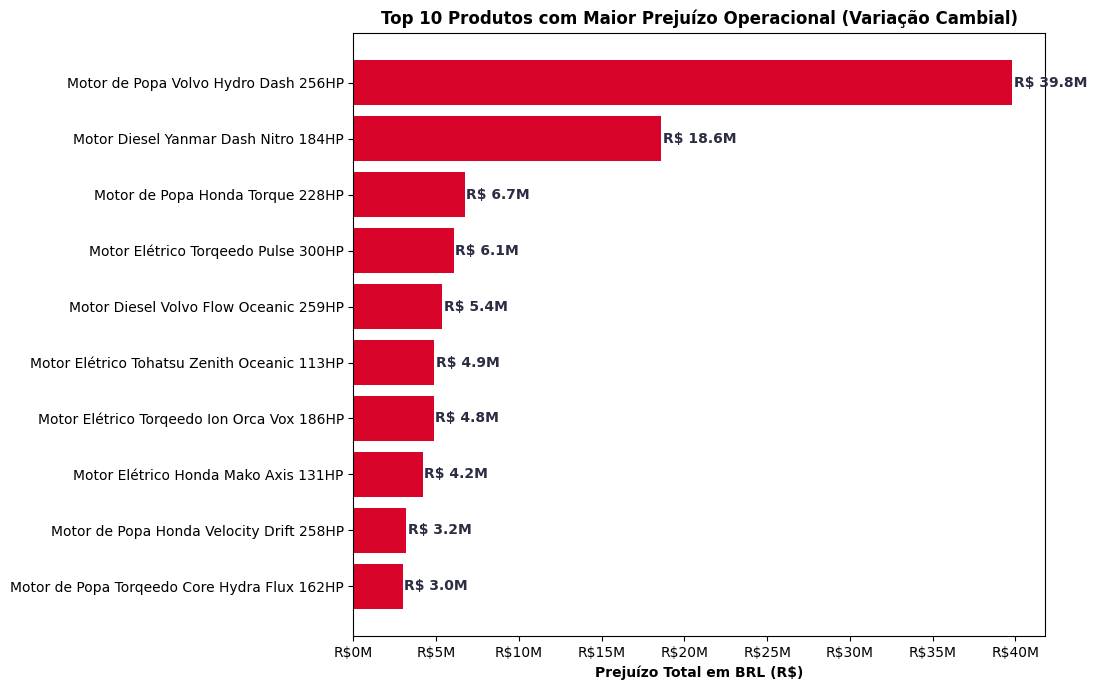

In [10]:
# Pegando o Top 10 maiores prejuízos
top10 = prej.head(10).copy()
top10["prejuizo_abs"] = top10["prejuizo_total"].abs()

plt.figure(figsize=(11, 7))
bars = plt.barh(top10["product_name"], top10["prejuizo_abs"], color='#d90429')

for bar in bars:
    plt.text(bar.get_width() + 100000, bar.get_y() + bar.get_height()/2, 
             f"R$ {bar.get_width()/1e6:.1f}M", 
             va='center', ha='left', fontsize=10, fontweight='bold', color='#2b2d42')

plt.xlabel("Prejuízo Total em BRL (R$)", fontweight='bold')
plt.title("Top 10 Produtos com Maior Prejuízo Operacional (Variação Cambial)", fontweight='bold')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x/1e6:.0f}M"))
plt.tight_layout()

# Exibe o gráfico no notebook e salva na pasta
plt.savefig('dashboard_prejuizos_bcb.png', dpi=300)
plt.show()

# Relatório Executivo: Análise de Prejuízos por Variação Cambial (2023–2024)

**Para:** Sr. Almir (Direção)
**Assunto:** Abertura da "Caixa Preta" Financeira - Cruzamento de Custos de Importação (USD) vs. Vendas (BRL)
**Data:** [Data Atual]

## 1. Resumo Executivo

Este relatório apresenta os resultados da investigação sobre potenciais vendas realizadas abaixo do custo de importação. O problema central residia na falta de sincronização entre o sistema de vendas (faturado em Reais - BRL) e o catálogo de fornecedores (comprado em Dólares - USD), agravado pelas flutuações diárias da taxa de câmbio.

Ao cruzar a data exata de cada venda com a cotação oficial do Dólar Comercial (Banco Central do Brasil) do respetivo dia, foi possível identificar com precisão as fugas de capital e os produtos que estão a corroer a margem de lucro da empresa.

## 2. Metodologia Aplicada

Para garantir a precisão absoluta dos números, a nossa equipa de dados executou as seguintes etapas:

- **Extração Oficial:** Consumo do histórico de taxas de câmbio diárias diretamente da base de dados do Banco Central (SGS).
- **Alinhamento Temporal:** Cada transação no ficheiro de vendas foi cruzada com a taxa de câmbio exata do dia em que ocorreu (ou do dia útil anterior, no caso de fins de semana).
- **Cálculo de Custo Real:** O custo em Dólar foi convertido para Reais no momento exato da venda (`Custo USD * Câmbio do Dia`), permitindo descobrir o verdadeiro lucro ou prejuízo da transação, ignorando impostos e fretes para isolar o problema cambial.

## 3. Principais Descobertas (Análise Objetiva)

A análise revelou falhas operacionais críticas na precificação de alguns produtos, destacando-se um caso de extrema urgência:

- **Qual produto concentra o maior prejuízo absoluto?**
O produto que gerou o maior rombo financeiro foi o **Motor de Popa Volvo Hydro Dash 256HP**, acumulando um prejuízo absoluto de **R$ 39.809.090,51** no período analisado.
- **O produto com maior prejuízo absoluto também é o que possui a maior percentagem de perda?Sim.** O *Motor de Popa Volvo Hydro Dash 256HP* não só lidera em volume financeiro perdido, como também apresenta a pior margem proporcional. A percentagem de perda deste equipamento foi de **63,13%**. Isto significa que, por cada R$ 100 de receita gerada com este motor, a empresa teve um custo real de importação de aproximadamente R$ 163 na altura da venda.

*(Nota: O painel visual / dashboard com o Top 10 dos produtos mais deficitários foi gerado em anexo no ficheiro `dashboard_prejuizos_bcb.png` para visualização rápida).*

## 4. Recomendações Estratégicas

Face a estes resultados, sugerimos as seguintes ações imediatas para estancar as perdas:

1. **Atualização Dinâmica de Preços (Pricing):** Implementar um mecanismo no sistema de vendas que atualize o preço mínimo de venda (em BRL) diariamente ou semanalmente, com base na cotação do Dólar atual.
2. **Bloqueio no ERP:** Criar uma regra de negócio no sistema que impeça os vendedores de fechar negócio caso o valor de venda em BRL seja inferior ao custo convertido daquele dia (alerta de margem negativa).
3. **Revisão de Catálogo:** Suspender temporariamente as vendas do *Motor de Popa Volvo Hydro Dash 256HP* (e dos restantes itens do Top 10 do gráfico) até que os seus preços de venda sejam reajustados à realidade cambial atual.


=== RESPOSTAS DA PARTE 3 ===
1. Produto com maior prejuízo absoluto: Motor de Popa Volvo Hydro Dash 256HP (R$ -39,809,090.51)
2. O produto com maior prejuízo absoluto também possui a maior porcentagem de perda? Sim (63.13% de perda)

✅ Sucesso! Gráfico salvo como 'dashboard_prejuizos_normalizado.png'


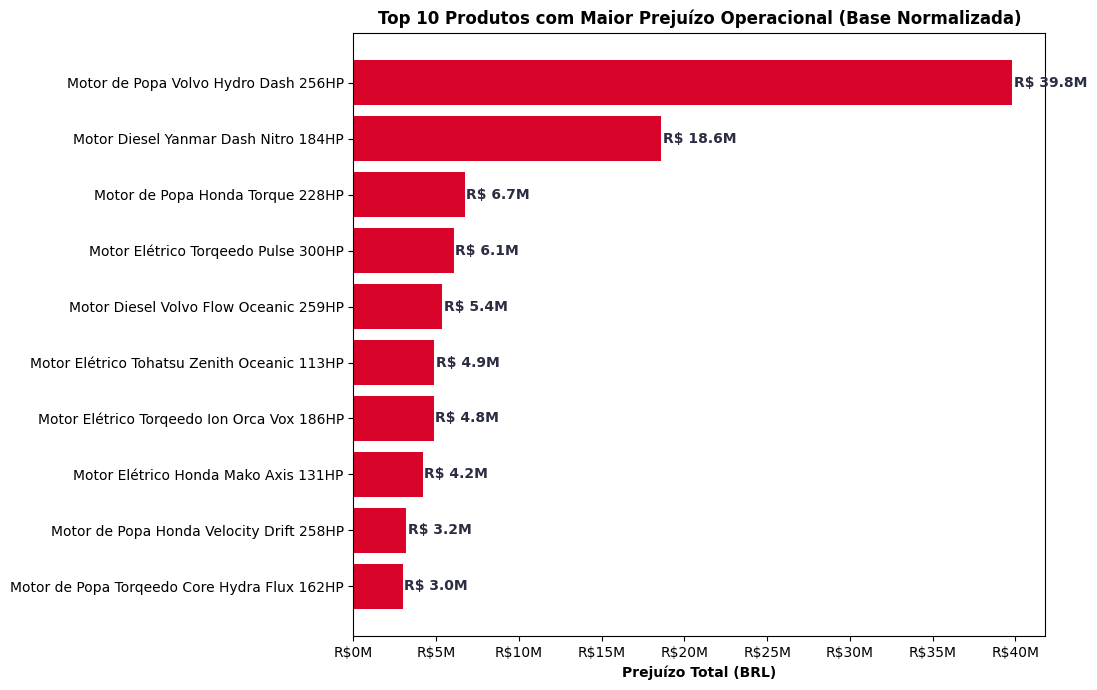

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import requests

# ==========================================
# 1. CARREGAR DADOS TRATADOS (Sua base nova)
# ==========================================
# ALERTA: Alterado para ler 'vendas_normalizadas.csv'
vendas = pd.read_csv('../datasets/vendas_normalizadas.csv')
custos = pd.read_csv('../datasets/custos_importacao.csv')

# ==========================================
# 2. CARREGAR CÂMBIO E TRATAR
# ==========================================
url = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.10813/dados"
params = {"formato": "json", "dataInicial": "01/01/2023", "dataFinal": "31/12/2024"}
response = requests.get(url, params=params)

df_cambio = pd.DataFrame(response.json())
df_cambio["data"] = pd.to_datetime(df_cambio["data"], dayfirst=True)
df_cambio["usd_brl"] = df_cambio["valor"].astype(float)

# Preencher finais de semana (ffill e bfill)
df_cambio = df_cambio.set_index('data')
calendario_completo = pd.date_range("2023-01-01", "2024-12-31", freq="D")
df_cambio = df_cambio.reindex(calendario_completo)
df_cambio['usd_brl'] = df_cambio['usd_brl'].ffill().bfill() 
df_cambio = df_cambio.reset_index().rename(columns={'index': 'data'})

# ==========================================
# 3. PADRONIZAR DATAS PARA O MERGE
# ==========================================
def parse_date(d):
    for fmt in ("%Y-%m-%d", "%d-%m-%Y", "%d/%m/%Y"):
        try:
            return pd.to_datetime(d, format=fmt)
        except:
            pass
    return pd.NaT

vendas["sale_date"] = vendas["sale_date"].apply(parse_date).dt.normalize()
df_cambio['data'] = pd.to_datetime(df_cambio['data']).dt.normalize()
custos["start_date"] = pd.to_datetime(custos["start_date"], errors='coerce').dt.normalize()

# ==========================================
# 4. CRUZAMENTOS (MERGES)
# ==========================================
# Merge 1: Vendas + Câmbio
vendas = pd.merge(vendas, df_cambio[['data', 'usd_brl']], left_on='sale_date', right_on='data', how='left')

# Merge 2: Vendas + Custos
vendas = vendas.sort_values("sale_date")
custos = custos.sort_values("start_date")

vendas_merged = pd.merge_asof(
    vendas, 
    custos[['product_id', 'start_date', 'usd_price', 'product_name']], 
    left_on="sale_date", 
    right_on="start_date", 
    left_by="id_product",  
    right_by="product_id", 
    direction="backward"
)

# ==========================================
# 5. CÁLCULO E MODELAGEM (PARTE 1)
# ==========================================
vendas_merged["custo_unit_brl"] = vendas_merged["usd_price"] * vendas_merged["usd_brl"]
vendas_merged["custo_total_brl"] = vendas_merged["custo_unit_brl"] * vendas_merged["qtd"]
vendas_merged["receita"] = vendas_merged["total"]
vendas_merged["resultado"] = vendas_merged["receita"] - vendas_merged["custo_total_brl"]
vendas_merged["prejuizo"] = vendas_merged["resultado"].apply(lambda x: x if x < 0 else 0)

# Agregação final
agg = vendas_merged.groupby(["id_product", "product_name"]).agg(
    receita_total = ("receita", "sum"),
    prejuizo_total = ("prejuizo", "sum")
).reset_index()

agg["pct_perda"] = (agg["prejuizo_total"].abs() / agg["receita_total"] * 100).round(2)
prej = agg[agg["prejuizo_total"] < 0].copy().sort_values("prejuizo_total")

# ==========================================
# 6. ANÁLISE OBJETIVA E GRÁFICO (PARTES 2 E 3)
# ==========================================
maior_abs = prej.loc[prej["prejuizo_total"].idxmin()]
maior_pct = prej.loc[prej["pct_perda"].idxmax()]

print("\n=== RESPOSTAS DA PARTE 3 ===")
print(f"1. Produto com maior prejuízo absoluto: {maior_abs['product_name']} (R$ {maior_abs['prejuizo_total']:,.2f})")
print(f"2. O produto com maior prejuízo absoluto também possui a maior porcentagem de perda? {'Sim' if maior_abs['product_name'] == maior_pct['product_name'] else 'Não'} ({maior_pct['pct_perda']:.2f}% de perda)")

# Gráfico
top10 = prej.head(10).copy()
top10["prejuizo_abs"] = top10["prejuizo_total"].abs()

plt.figure(figsize=(16, 7))
bars = plt.barh(top10["product_name"], top10["prejuizo_abs"], color='#d90429')

for bar in bars:
    plt.text(bar.get_width() + 100000, bar.get_y() + bar.get_height()/2, 
             f"R$ {bar.get_width()/1e6:.1f}M", 
             va='center', ha='left', fontsize=10, fontweight='bold', color='#2b2d42')

plt.xlabel("Prejuízo Total (BRL)", fontweight='bold')
plt.title("Top 10 Produtos com Maior Prejuízo Operacional (Base Normalizada)", fontweight='bold')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x/1e6:.0f}M"))
plt.tight_layout()

plt.savefig('dashboard_prejuizos_normalizado.png', dpi=300)
print("\n✅ Sucesso! Gráfico salvo como 'dashboard_prejuizos_normalizado.png'")